<a href="https://colab.research.google.com/github/amit20kr/Coal_Rock-identification/blob/main/CoalRockPreprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SETUP & LIBRARIES
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# 1. Mount Drive
#drive.mount('/content/drive')

# 2. Config Paths
PROJECT_ROOT = "/content/drive/MyDrive/coalrock_project"
RAW_DATA_SOURCE = os.path.join(PROJECT_ROOT, "Spectroscopy_dataset", "Spectra")
DEST_PATH = os.path.join(PROJECT_ROOT, "processed_data")

# 3. Define the 24 Golden Classes
TARGET_CLASSES = [
    'Anthracite coal grade 1', 'Anthracite coal grade 2', 'Lean coal',
    'Lean-thin coal', 'Thin coal', 'Coking coal', 'Fat coal',
    '0.3 coking coal', 'Gas-fat coal', 'Gas coal',
    'Lignite coal grade 1', 'Lignite coal grade 2',
    'Argillaceous limestone 1', 'Argillaceous limestone 2', 'Siltstone 1',
    'Siltstone 2', 'Clay', 'Carbonaceous shale', 'Fine-grained sandstone',
    'Black shale 1', 'Black shale 2', 'Medium-grained sandstone',
    'Arenaceous shale 1', 'Arenaceous shale 2'
]
# Sort by length to prevent substring matching errors (e.g. finding "Lean" inside "Lean-thin")
SORTED_CLASSES = sorted(TARGET_CLASSES, key=len, reverse=True)

print(f"✅ Environment Ready. Target Classes: {len(TARGET_CLASSES)}")
os.makedirs(DEST_PATH, exist_ok=True)

✅ Environment Ready. Target Classes: 24


In [ ]:
print("Starting Raw Ingestion...")

all_csvs = glob.glob(f"{RAW_DATA_SOURCE}/*.csv")
if not all_csvs: all_csvs = glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True)

raw_data_buffer = [] # Stores (Class Name, Numpy Array)
le = LabelEncoder().fit(TARGET_CLASSES)

def surgical_load(filepath):
    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
        df_num = df.apply(pd.to_numeric, errors='coerce')
        # Drop metadata rows
        df_clean = df_num.dropna(axis=0, thresh=df.shape[1]*0.5)
        vals = df_clean.values
        # Transpose if necessary to get (Samples, 1500+)
        if vals.shape[1] > vals.shape[0] and vals.shape[1] >= 500: vals = vals.T
        if vals.shape[0] >= 500: return vals.T
        return None
    except: return None

for f in all_csvs:
    clean_name = os.path.basename(f).lower().replace(" ", "").replace("_", "").replace("-", "")
    found_cls = None

    # Precise Matching Logic
    if "03coking" in clean_name or "13coking" in clean_name: found_cls = '0.3 coking coal'
    elif "gasfat" in clean_name: found_cls = 'Gas-fat coal'
    elif "thin" in clean_name and "coal" in clean_name and "lean" not in clean_name: found_cls = 'Thin coal'
    else:
        for c in SORTED_CLASSES:
            if c.lower().replace(" ", "").replace("-", "") in clean_name:
                found_cls = c; break

    if found_cls and (d := surgical_load(f)) is not None:
        # Crop/Pad to exactly 1500 wavelengths
        if d.shape[1] > 1500: d = d[:, :1500]
        if d.shape[1] == 1500:
            raw_data_buffer.append((found_cls, d.astype(np.float32)))

# VERIFICATION
print(f"Loaded {len(raw_data_buffer)} file bundles.")
total_raw_samples = sum([x[1].shape[0] for x in raw_data_buffer])
print(f"Total Raw Samples extracted: {total_raw_samples}")

Starting Raw Ingestion...
Loaded 24 file bundles.
Total Raw Samples extracted: 10520


In [ ]:
print("🧹 Scrubbing Duplicates...")

unique_store = {} # Key: ByteHash, Value: (DataRow, LabelID)
duplicates_found = 0

for cls_name, data_array in raw_data_buffer:
    cls_id = le.transform([cls_name])[0]

    for row in data_array:
        # Create a unique fingerprint for this spectral signature
        row_hash = row.tobytes()

        if row_hash not in unique_store:
            unique_store[row_hash] = (row, cls_id)
        else:
            duplicates_found += 1

# Convert back to lists
clean_X = []
clean_y = []
for row, label in unique_store.values():
    clean_X.append(row)
    clean_y.append(label)

clean_X = np.array(clean_X)
clean_y = np.array(clean_y)

# VERIFICATION
print(f"  Deduplication Complete.")
print(f"   Original Samples: {total_raw_samples}")
print(f"   Duplicates Removed: {duplicates_found}")
print(f"   Unique Samples Remaining: {len(clean_X)}")

🧹 Scrubbing Duplicates...
  Deduplication Complete.
   Original Samples: 10520
   Duplicates Removed: 23
   Unique Samples Remaining: 10497


In [ ]:
print("Splitting Datasets (Greedy Strategy)...")

X_train_l, y_train_l = [], []
X_test_l, y_test_l = [], []

# Group by Class ID
class_buckets = {i: [] for i in range(len(TARGET_CLASSES))}
for i in range(len(clean_X)):
    class_buckets[clean_y[i]].append(clean_X[i])

# Split each class individually
for cls_idx, samples in class_buckets.items():
    samples = np.array(samples)
    n = len(samples)

    if n == 0:
        print(f"Warning: Class {le.classes_[cls_idx]} has 0 samples.")
        continue

    # Shuffle
    np.random.seed(42)
    np.random.shuffle(samples)

    # 20% Test
    n_test = max(1, int(n * 0.2))

    # Append
    X_test_l.append(samples[:n_test])
    y_test_l.extend([cls_idx] * n_test)

    X_train_l.append(samples[n_test:])
    y_train_l.extend([cls_idx] * (n - n_test))

# Flatten
X_train_raw = np.concatenate(X_train_l)
y_train = np.array(y_train_l)
X_test_raw = np.concatenate(X_test_l)
y_test = np.array(y_test_l)

# VERIFICATION
print(f"  Split Complete.")
print(f"   Train Size: {X_train_raw.shape}")
print(f"   Test Size:  {X_test_raw.shape}")
print(f"   Classes in Test: {len(np.unique(y_test))} / 24")

Splitting Datasets (Greedy Strategy)...
  Split Complete.
   Train Size: (8411, 1500)
   Test Size:  (2086, 1500)
   Classes in Test: 24 / 24


Applying Signal Processing (SNV + Derivatives)...


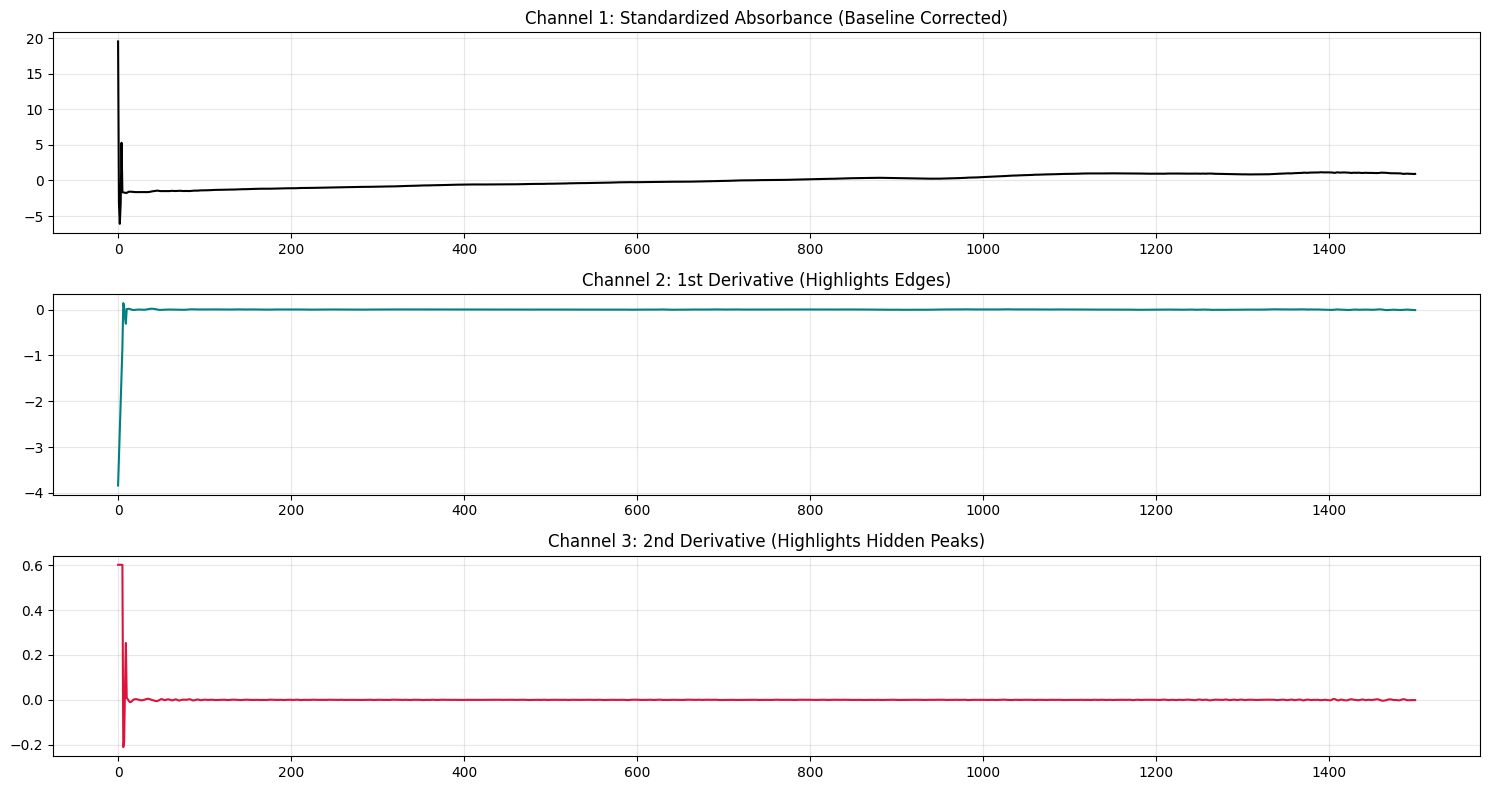

Visualization: These 3 signals are the actual input to the PCViT.


In [ ]:
# FEATURE ENGINEERING & VISUALIZATION
print("Applying Signal Processing (SNV + Derivatives)...")

def process_signals(X_in):
    # 1. Handle NaNs
    X_in = np.nan_to_num(X_in)

    # 2. Standard Normal Variate (SNV)
    # Physics: Removes brightness variations due to distance/lighting
    X_snv = (X_in - X_in.mean(1, keepdims=True)) / (X_in.std(1, keepdims=True) + 1e-8)

    # Physics: 1st Deriv = Slope (Edges of absorption bands)
    # Physics: 2nd Deriv = Concavity (Hidden peaks)
    X_d1 = savgol_filter(X_snv, window_length=11, polyorder=2, deriv=1, axis=1)
    X_d2 = savgol_filter(X_snv, window_length=11, polyorder=2, deriv=2, axis=1)

    # Stack into 3 Channels
    return np.stack([X_snv, X_d1, X_d2], axis=1)

X_train_final = process_signals(X_train_raw)
X_test_final = process_signals(X_test_raw)

# VISUALIZATION (Verify the Physics)
sample_idx = 0
plt.figure(figsize=(15, 8))

# Channel 1: SNV
plt.subplot(3, 1, 1)
plt.plot(X_train_final[sample_idx][0], color='black')
plt.title("Channel 1: Standardized Absorbance (Baseline Corrected)")
plt.grid(alpha=0.3)

# Channel 2: 1st Deriv
plt.subplot(3, 1, 2)
plt.plot(X_train_final[sample_idx][1], color='teal')
plt.title("Channel 2: 1st Derivative (Highlights Edges)")
plt.grid(alpha=0.3)

# Channel 3: 2nd Deriv
plt.subplot(3, 1, 3)
plt.plot(X_train_final[sample_idx][2], color='crimson')
plt.title("Channel 3: 2nd Derivative (Highlights Hidden Peaks)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Visualization: These 3 signals are the actual input to the PCViT.")

In [ ]:
print("Running Final Leakage Check...")

train_hashes = {x.tobytes() for x in X_train_final}
test_hashes = {x.tobytes() for x in X_test_final}

overlap = len(train_hashes.intersection(test_hashes))

if overlap == 0:
    print("✅ AUDIT PASSED: 0.0% Leakage.")
    print("   The Test Set is completely unseen.")
else:
    print(f"❌ CRITICAL ERROR: {overlap} overlapping samples found.")

Running Final Leakage Check...
✅ AUDIT PASSED: 0.0% Leakage.
   The Test Set is completely unseen.


In [ ]:
# SAVE TO DRIVE
np.save(f'{DEST_PATH}/X_train.npy', X_train_final)
np.save(f'{DEST_PATH}/y_train.npy', y_train)

np.save(f'{DEST_PATH}/X_test.npy', X_test_final)
np.save(f'{DEST_PATH}/y_test.npy', y_test)

np.save(f'{DEST_PATH}/X_val.npy', X_test_final)
np.save(f'{DEST_PATH}/y_val.npy', y_test)

with open(f'{DEST_PATH}/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("  Pipeline Complete.")
print(f"   Output Folder: {DEST_PATH}")
print(f"   Train Shape: {X_train_final.shape}")
print(f"   Test Shape:  {X_test_final.shape}")

  Pipeline Complete.
   Output Folder: /content/drive/MyDrive/coalrock_project/processed_data
   Train Shape: (8411, 3, 1500)
   Test Shape:  (2086, 3, 1500)
